# Advanced Underemployment Forecast (Holt's Linear Trend Method)
This notebook uses the `sc_silver.underemployment_rate` table to forecast underemployment rates until 2030, leveraging **Holt's Linear Trend** (Double Exponential Smoothing) which accounts for both modern business momentum and long-term trends.

## 1. Imports and Setup
Import necessary libraries and configure the path to access local modules.

In [20]:
import pandas as pd
from statsmodels.tsa.holtwinters import Holt
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Set path to parent directory for imports
sys.path.append('..')
from utils.db_utils import read_table, write_table

## 2. Data Extraction & Quarterly Interpolation
Fetch from Silver layer, convert units, and interpolate to Quarterly resolution for smoother analysis.

In [21]:
query = """
SELECT 
    year::int, 
    underemp_type, 
    total_underemp, 
    total_emp_graduate 
FROM sc_silver.underemployment_rate
ORDER BY year, underemp_type;
"""
df_silver = read_table(query)

# Pivot to Wide format
df_pivot = df_silver.pivot(index='year', columns='underemp_type', values=['total_underemp', 'total_emp_graduate'])
df_pivot.columns = [f"{col[0]}_{col[1]}" for col in df_pivot.columns]
df_pivot['total_emp_graduate'] = df_pivot['total_emp_graduate_skill']
df_pivot = df_pivot[['total_underemp_skill', 'total_underemp_time', 'total_emp_graduate']].reset_index()

# Upsample and Interpolate to Quarterly
df_pivot['date'] = pd.to_datetime(df_pivot['year'].astype(str) + '-01-01')
df_q = df_pivot.set_index('date').resample('QS').asfreq().interpolate(method='linear')

print("Interpolated Quarterly Historical Data (Preview):")
display(df_q.head(4))

Interpolated Quarterly Historical Data (Preview):


,year,total_underemp_skill,total_underemp_time,total_emp_graduate
date,,,,
2016-01-01,2016.00,797200.0,34200.0,3476500.0
2016-04-01,2016.25,823275.0,34900.0,3527450.0
2016-07-01,2016.50,849350.0,35600.0,3578400.0
2016-10-01,2016.75,875425.0,36300.0,3629350.0


## 3. Holt's Linear Trend Modeling
Applying Double Exponential Smoothing to predict levels and trends for each workforce metric.

In [ ]:
# Forecast until end of 2030 (27 quarters ahead from head of 2024)
last_date = df_q.index.max()
forecast_steps = 27 

def holt_forecast(series_name):
    # Initialize and fit Holt's Linear Trend Model
    # trend='add' captures the linear growth over time
    model = Holt(df_q[series_name], initialization_method="estimated").fit(optimized=True)
    print(f"--- Holt's Parameters for: {series_name.upper()} ---")
    print(f"Smoothing Level (alpha): {model.params['smoothing_level']:.4f}")
    print(f"Smoothing Trend (beta): {model.params['smoothing_trend']:.4f}")
    
    return model.forecast(forecast_steps)

# Execute and store results
skill_future = holt_forecast('total_underemp_skill')
time_future = holt_forecast('total_underemp_time')
grads_future = holt_forecast('total_emp_graduate')

# Combine future results
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=3), periods=forecast_steps, freq='QS')
future_data = pd.DataFrame({
    'total_underemp_skill': skill_future.values,
    'total_underemp_time': time_future.values,
    'total_emp_graduate': grads_future.values
}, index=future_dates)

# Combine with history
all_data_q = pd.concat([df_q.drop(columns=['year']), future_data])
all_data_q = all_data_q.clip(lower=0)

print("\n--- HOLT'S LINEAR FORECAST COMPLETE ---")

--- Holt's Parameters for: TOTAL_UNDEREMP_SKILL ---
Smoothing Level (alpha): 0.9950
Smoothing Trend (beta): 0.9950
--- Holt's Parameters for: TOTAL_UNDEREMP_TIME ---
Smoothing Level (alpha): 0.9950
Smoothing Trend (beta): 0.9950
--- Holt's Parameters for: TOTAL_EMP_GRADUATE ---
Smoothing Level (alpha): 0.9959
Smoothing Trend (beta): 0.9762

--- HOLT'S LINEAR FORECAST COMPLETE ---


c:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


## 4. Derived Rate Calculations
Re-aggregating the counts into percentages for the final underemployment story.

In [23]:
# Calculate rates
all_data_q['underemp_skill_rate_pct'] = (all_data_q['total_underemp_skill'] / all_data_q['total_emp_graduate']) * 100
all_data_q['underemp_time_rate_pct'] = (all_data_q['total_underemp_time'] / all_data_q['total_emp_graduate']) * 100
all_data_q['underemp_aggregate_rate_pct'] = all_data_q['underemp_skill_rate_pct'] + all_data_q['underemp_time_rate_pct']

print("Rates Calculated.")
display(all_data_q.tail(8))

Rates Calculated.


,total_underemp_skill,total_underemp_time,total_emp_graduate,underemp_skill_rate_pct,underemp_time_rate_pct,underemp_aggregate_rate_pct
2029-01-01,1.898392e+06,71594.941743,6.079500e+06,31.226121,1.177645,32.403767
2029-04-01,1.913292e+06,73094.688416,6.134650e+06,31.188277,1.191505,32.379783
2029-07-01,1.928191e+06,74594.435090,6.189800e+06,31.151107,1.205119,32.356226
2029-10-01,1.943091e+06,76094.181763,6.244950e+06,31.114594,1.218491,32.333086
2030-01-01,1.957990e+06,77593.928437,6.300100e+06,31.078720,1.231630,32.310350
2030-04-01,1.972890e+06,79093.675110,6.355250e+06,31.043469,1.244541,32.288010
2030-07-01,1.987790e+06,80593.421784,6.410400e+06,31.008824,1.257229,32.266053
2030-10-01,2.002689e+06,82093.168458,6.465550e+06,30.974770,1.269701,32.244471


## 5. Visual Monitoring
Comparing Skill, Time, and Aggregate trends side-by-side using the Holt projections.

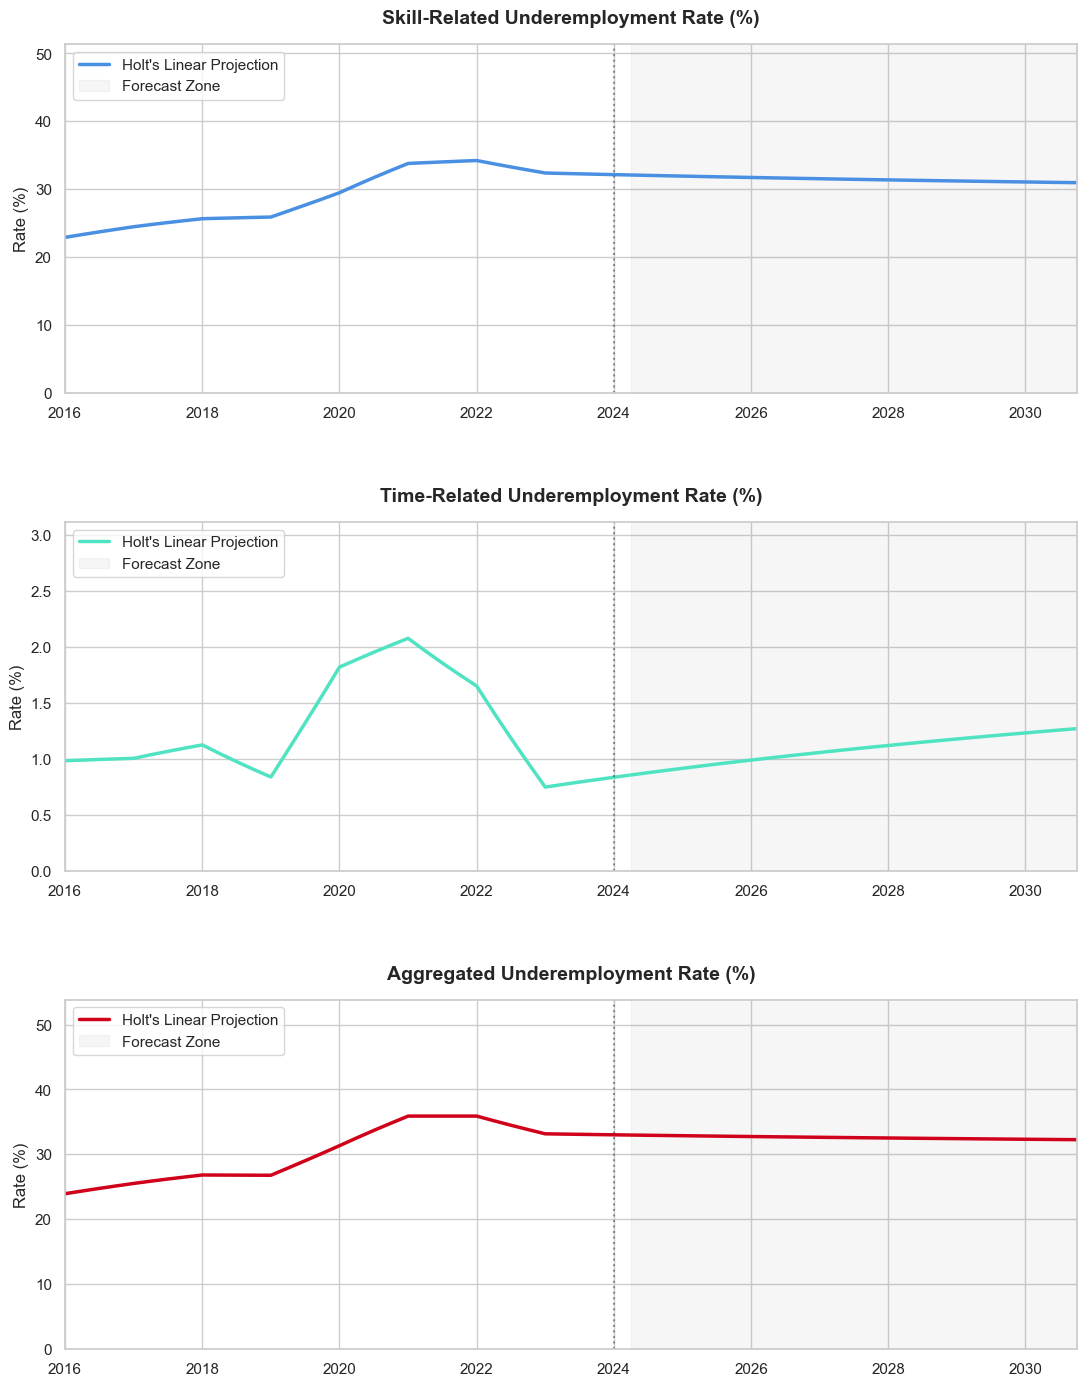

In [24]:
sns.set_theme(style="whitegrid")
metrics = [
    ('underemp_skill_rate_pct', 'Skill-Related Underemployment Rate (%)', '#4A90E2'),
    ('underemp_time_rate_pct', 'Time-Related Underemployment Rate (%)', '#50E3C2'),
    ('underemp_aggregate_rate_pct', 'Aggregated Underemployment Rate (%)', '#D0021B')
]

fig, axes = plt.subplots(3, 1, figsize=(12, 15))
last_hist_date = df_q.index.max()

for i, (col, title, color) in enumerate(metrics):
    ax = axes[i]
    ax.plot(all_data_q.index, all_data_q[col], color=color, linewidth=2.5, label='Holt\'s Linear Projection')
    ax.axvline(x=last_hist_date, color='#333333', linestyle=':', alpha=0.5)
    ax.fill_between(all_data_q.index, 0, 100, where=(all_data_q.index > last_hist_date), color='grey', alpha=0.07, label='Forecast Zone')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Rate (%)')
    ax.set_ylim(0, max(all_data_q[col]) * 1.5)
    ax.set_xlim(all_data_q.index.min(), all_data_q.index.max())
    ax.legend(loc='upper left', frameon=True)

plt.tight_layout(pad=4.0)
plt.show()

In [25]:
# 1. Select relevant columns and prepare dataframe
df_prepared = all_data_q[[
    'underemp_skill_rate_pct', 
    'underemp_time_rate_pct'
]].copy()

# 2. Ensure date is a column
df_prepared.index.name = 'date'
df_prepared = df_prepared.reset_index()

# 3. Reshape from Wide to Long format to create 'unemploymern_type' and 'underemp_rate_pct'
df_final = df_prepared.melt(
    id_vars=['date'], 
    value_vars=['underemp_skill_rate_pct', 'underemp_time_rate_pct'],
    var_name='unemploymern_type', 
    value_name='underemp_rate_pct'
)

# 4. Map the type values to 'skill' and 'time'
df_final['unemploymern_type'] = df_final['unemploymern_type'].map({
    'underemp_skill_rate_pct': 'skill',
    'underemp_time_rate_pct': 'time'
})

# 5. Add 'source' labels based on historical threshold (2024)
cutoff = pd.Timestamp('2024-01-01')
df_final['source'] = df_final['date'].apply(
    lambda x: 'historical' if x <= cutoff else 'forecast'
)

# 6. Final Column Selection and Ordering
df_final = df_final[['date', 'unemploymern_type', 'underemp_rate_pct', 'source']]

# 7. Preview the resulting format
print("Finalized Underemployment Data (Long Format):")
display(df_final.head())

Finalized Underemployment Data (Long Format):


,date,unemploymern_type,underemp_rate_pct,source
0,2016-01-01,skill,22.931109,historical
1,2016-04-01,skill,23.339098,historical
2,2016-07-01,skill,23.735468,historical
3,2016-10-01,skill,24.120710,historical
4,2017-01-01,skill,24.495286,historical


## 6. Supabase Integration
Write the finalized long-format forecast data to the Silver layer in Supabase for Power BI access.

In [26]:
# Write to sc_silver.underemployment_forecast
try:
    write_table(df_final, 'sc_silver', 'forecast_underemployment')
    print("Successfully written to Supabase: sc_silver.forecast_underemployment")
except Exception as e:
    print(f"Failed to write to Supabase: {e}")

Table sc_silver.forecast_underemployment written successfully.
Successfully written to Supabase: sc_silver.forecast_underemployment
